In [1]:
import sys
sys.path.append('/Users/nagairyousuke/Documents/kashima_lab/master_paper')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('husl')

# reg_suffix = "s47_s49_s50_s58_s67_s70_s74_s77_s79_s86_s277_s278_s279_s280_s309_L1_0.001"
# reg_suffix = "s47_s49_s50_s58_s67_s74_s277_s278_s279_s280_L1_0.001"
# reg_suffix = "s13_s18_s47_s49_s50_s58_s67_s70_s74_s77_s85_s277_s279_s280_s311_L1_0.001"
# reg_suffix = "s10_s13_s14_s15_s47_s49_s58_s67_s70_s74_s77_s79_s86_s277_s278_s279_s280_s309_L1_0.001" # よかった
# reg_suffix = "s10_s13_s14_s15_s47_s49_s58_s70_s74_s77_s79_s277_s278_s279_s280_L1_0.001" # k=15
reg_suffix = "s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1_0.001" # k=10
# reg_suffix = "s58_s74_s277_s279_s280_L1_0.001" # k=5
# reg_suffix = "s47_s49_s277_s279_s280_L1_0.001_L1_0.001"

print(f"結果ディレクトリサフィックス: {reg_suffix}")
print("="*80)

結果ディレクトリサフィックス: s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1_0.001


## 1. Load Results

In [2]:
# Load analysis results
analysis_dir = Path(f'../../analysis/assistments_2009_2010/{reg_suffix}')

print(f"読み込み元: {analysis_dir}")
print()

# ファイルの存在チェック
if not analysis_dir.exists():
    print(f"⚠️ 警告: ディレクトリが存在しません: {analysis_dir}")
    print(f"先に分析スクリプトを実行してください:")
    print(f"  python -m analysis.assistments_2009_2010.run_analysis --reg-type {REG_TYPE} --reg-lambda {REG_LAMBDA}")
else:
    stats_file = analysis_dir / 'statistics.csv'
    wins_file = analysis_dir / 'win_rates.csv'
    wilcoxon_file = analysis_dir / 'wilcoxon_results.csv'
    
    if not all([stats_file.exists(), wins_file.exists(), wilcoxon_file.exists()]):
        print(f"⚠️ 警告: 必要なファイルが不足しています")
        print(f"  statistics.csv: {stats_file.exists()}")
        print(f"  win_rates.csv: {wins_file.exists()}")
        print(f"  wilcoxon_results.csv: {wilcoxon_file.exists()}")
    else:
        df_stats = pd.read_csv(stats_file)
        df_wins = pd.read_csv(wins_file)
        df_wilcoxon = pd.read_csv(wilcoxon_file)
        
        print("Statistics:")
        display(df_stats)
        
        print("\nWin Rates:")
        display(df_wins)
        
        print("\nWilcoxon Test Results:")
        display(df_wilcoxon)

読み込み元: ../../analysis/assistments_2009_2010/s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1_0.001

Statistics:


,dataset,method,n_samples,acc_mean,acc_std,spa_mean,spa_std,ace_mean,ace_std,mse_mean,mse_std
0,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,proposed,100,0.771478,0.050619,0.766578,0.025559,0.518410,0.073998,0.050806,0.007327
1,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,full_information,100,0.845338,0.045253,0.793000,0.023365,0.454560,0.066770,0.041294,0.006185
2,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,popularity,100,0.783759,0.049823,0.757872,0.024771,0.526832,0.069251,0.050722,0.006686
3,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,simple_markov,100,0.703311,0.055436,0.758689,0.034569,2.729841,1.010963,0.073851,0.013666
4,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,random,100,0.616364,0.056132,0.707601,0.027067,0.646957,0.077327,0.063565,0.006806
5,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,bayesian_network,100,0.743044,0.055483,0.758024,0.034369,0.662290,0.145008,0.068207,0.012706



Win Rates:


,dataset,baseline,n_trials,acc_wins,acc_win_rate,spa_wins,spa_win_rate,ace_wins,ace_win_rate,mse_wins,mse_win_rate
0,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,full_information,100,11,0.11,4,0.04,2,0.02,1,0.01
1,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,popularity,100,30,0.30,75,0.75,64,0.64,53,0.53
2,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,simple_markov,100,88,0.88,60,0.60,100,1.00,100,1.00
3,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,random,100,99,0.99,100,1.00,100,1.00,100,1.00
4,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,bayesian_network,100,72,0.72,67,0.67,97,0.97,98,0.98



Wilcoxon Test Results:


,dataset,metric,baseline,statistic,p_value,significant,alpha
0,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,acc,full_information,131.0,1.000000e+00,False,0.05
1,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,spa,full_information,23.0,1.000000e+00,False,0.05
2,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,ace,full_information,3.0,1.000000e+00,False,0.05
3,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,mse,full_information,1.0,1.000000e+00,False,0.05
4,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,acc,popularity,959.0,9.981175e-01,False,0.05
5,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,spa,popularity,4233.0,2.144302e-09,True,0.05
6,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,ace,popularity,3329.0,2.851264e-03,True,0.05
7,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,mse,popularity,2563.0,4.480236e-01,False,0.05
8,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,acc,simple_markov,4764.5,6.685484e-16,True,0.05
9,s47_s49_s58_s70_s74_s79_s277_s278_s279_s280_L1...,spa,simple_markov,3323.0,3.036782e-03,True,0.05


## 2. Performance Comparison (Mean ± Std)

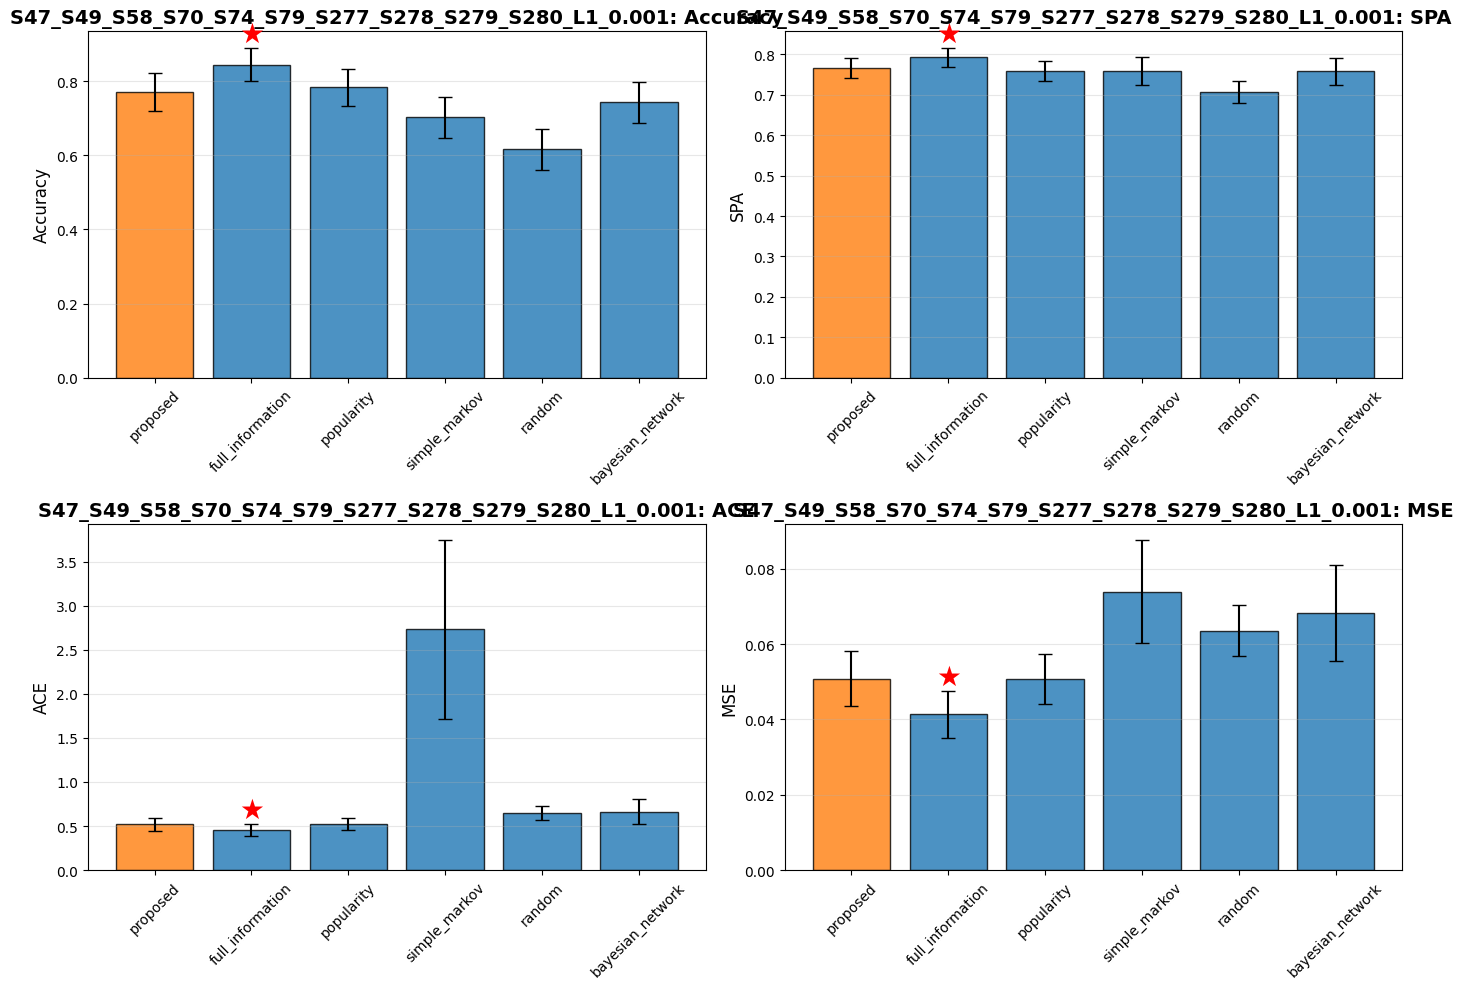

In [3]:
# Metrics to visualize
metrics = ['acc', 'spa', 'ace', 'mse']
metric_names = {
    'acc': 'Accuracy',
    'spa': 'SPA',
    'ace': 'ACE',
    'mse': 'MSE',
    'kl': 'KL Divergence',
    'hd': 'Hamming Distance',
    'jsd': 'JSD'
}

higher_is_better = {
    'acc': True,
    'spa': True,
    'ace': False,
    'mse': False,
    'kl': False,
    'hd': False,
    'jsd': False
}

for dataset in df_stats['dataset'].unique():
    df_dataset = df_stats[df_stats['dataset'] == dataset]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        methods = df_dataset['method'].values
        means = df_dataset[f'{metric}_mean'].values
        stds = df_dataset[f'{metric}_std'].values
        
        # Color proposed method differently
        colors = ['#ff7f0e' if m == 'proposed' else '#1f77b4' for m in methods]
        
        bars = ax.bar(methods, means, yerr=stds, capsize=5, alpha=0.8, color=colors, edgecolor='black')
        
        ax.set_ylabel(metric_names[metric], fontsize=12)
        ax.set_title(f'{dataset.upper()}: {metric_names[metric]}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        # Add best indicator
        if higher_is_better[metric]:
            best_idx = np.argmax(means)
        else:
            best_idx = np.argmin(means)
        
        ax.text(best_idx, means[best_idx] + stds[best_idx], '★', 
                ha='center', va='bottom', fontsize=20, color='red')
    
    plt.tight_layout()
    plt.show()

## 3. Win Rates Visualization

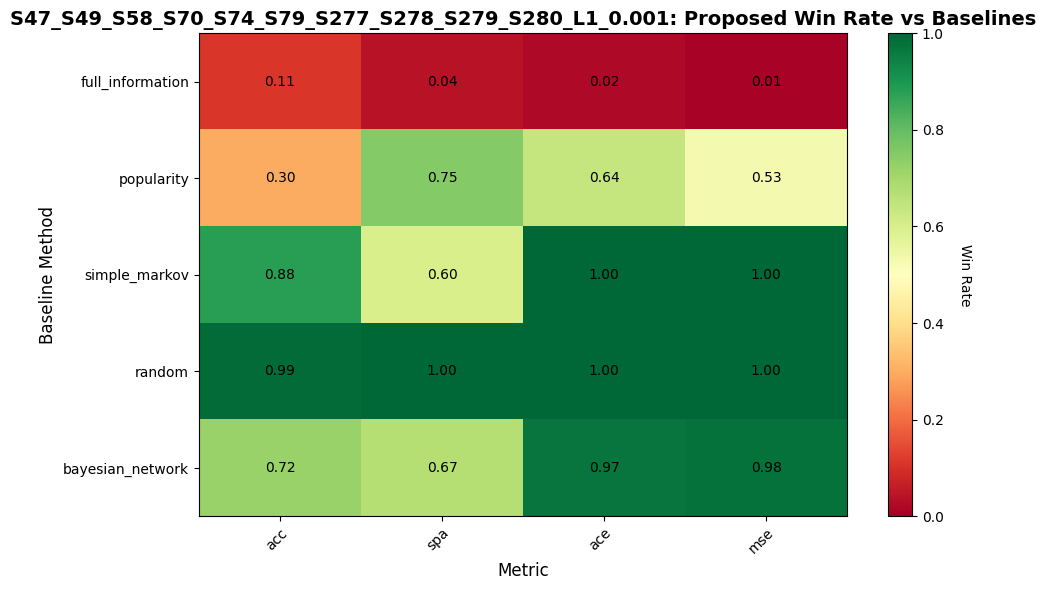

In [4]:
# Win rates heatmap
for dataset in df_wins['dataset'].unique():
    df_dataset = df_wins[df_wins['dataset'] == dataset]
    
    # Extract win rate columns
    win_rate_cols = [col for col in df_dataset.columns if col.endswith('_win_rate')]
    
    if not win_rate_cols:
        print(f"No win rate data for {dataset}")
        continue
    
    # Prepare data for heatmap
    baselines = df_dataset['baseline'].values
    metrics_for_heatmap = [col.replace('_win_rate', '') for col in win_rate_cols]
    
    win_rate_matrix = df_dataset[win_rate_cols].values
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    
    im = ax.imshow(win_rate_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Set ticks
    ax.set_xticks(np.arange(len(metrics_for_heatmap)))
    ax.set_yticks(np.arange(len(baselines)))
    ax.set_xticklabels(metrics_for_heatmap)
    ax.set_yticklabels(baselines)
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    for i in range(len(baselines)):
        for j in range(len(metrics_for_heatmap)):
            text = ax.text(j, i, f'{win_rate_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    ax.set_title(f'{dataset.upper()}: Proposed Win Rate vs Baselines', fontsize=14, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=12)
    ax.set_ylabel('Baseline Method', fontsize=12)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Win Rate', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()

## 4. Win Counts Bar Chart

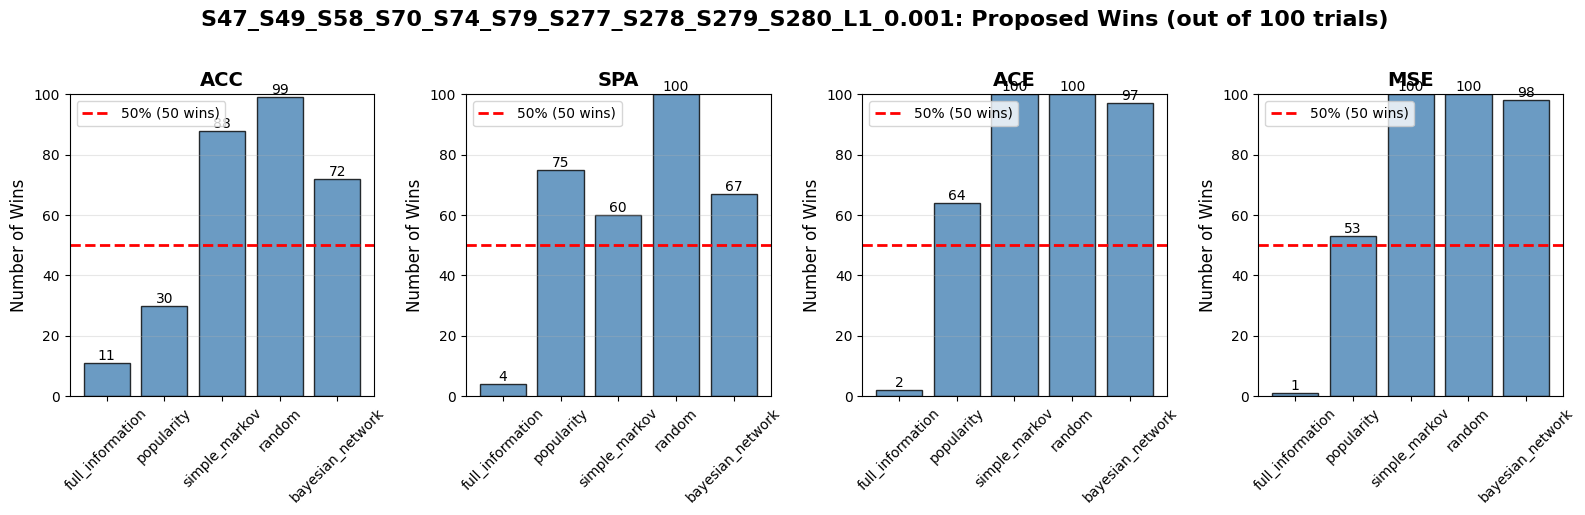

In [5]:
# Win counts bar chart
for dataset in df_wins['dataset'].unique():
    df_dataset = df_wins[df_wins['dataset'] == dataset]
    
    win_cols = [col for col in df_dataset.columns if col.endswith('_wins')]
    
    if not win_cols:
        continue
    
    fig, axes = plt.subplots(1, len(win_cols), figsize=(len(win_cols)*4, 5))
    
    if len(win_cols) == 1:
        axes = [axes]
    
    for idx, win_col in enumerate(win_cols):
        metric = win_col.replace('_wins', '')
        ax = axes[idx]
        
        baselines = df_dataset['baseline'].values
        wins = df_dataset[win_col].values
        n_trials = df_dataset['n_trials'].values[0]
        
        bars = ax.bar(baselines, wins, alpha=0.8, color='steelblue', edgecolor='black')
        ax.axhline(y=n_trials/2, color='red', linestyle='--', linewidth=2, label=f'50% ({n_trials//2} wins)')
        
        ax.set_ylabel('Number of Wins', fontsize=12)
        ax.set_title(f'{metric.upper()}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylim(0, n_trials)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=10)
    
    fig.suptitle(f'{dataset.upper()}: Proposed Wins (out of {n_trials} trials)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Wilcoxon Test Results

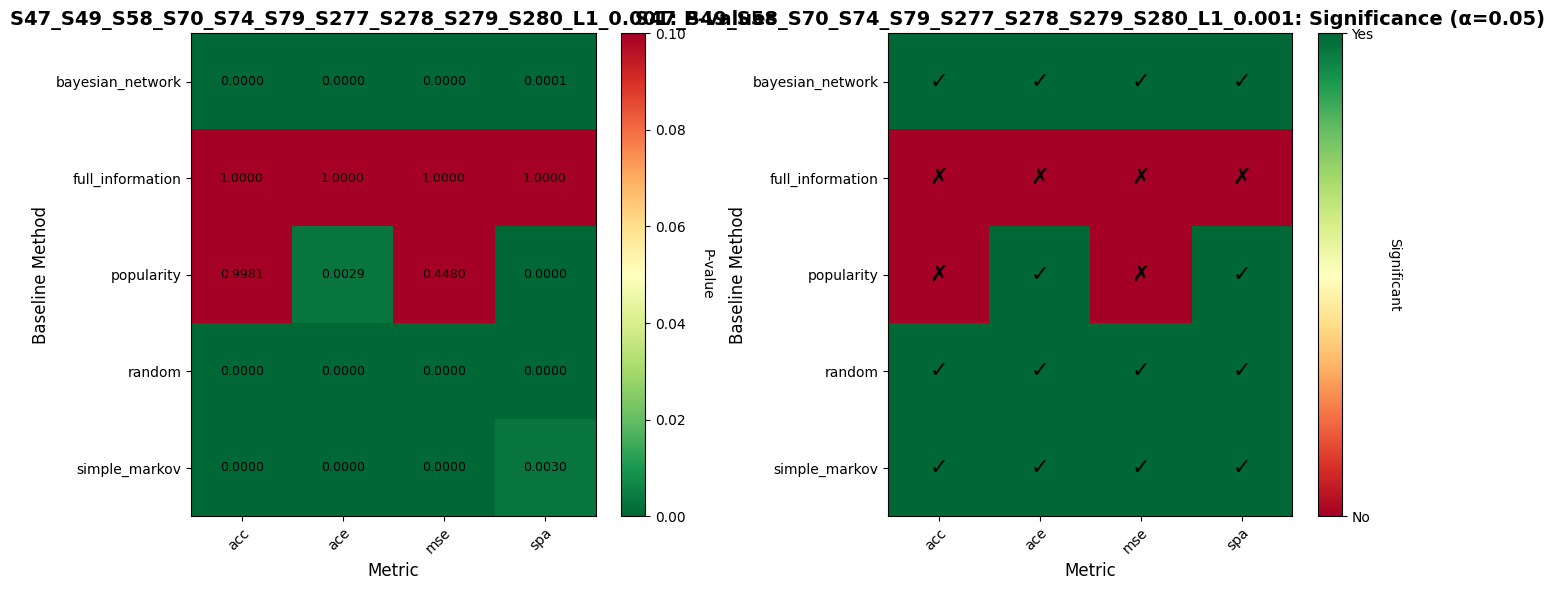


S47_S49_S58_S70_S74_S79_S277_S278_S279_S280_L1_0.001 - Significance Summary:
  Significant results: 14 / 20 (70.0%)

  Significant cases:


,metric,baseline,p_value
5,spa,popularity,2.144302e-09
6,ace,popularity,2.851264e-03
8,acc,simple_markov,6.685484e-16
9,spa,simple_markov,3.036782e-03
10,ace,simple_markov,1.948280e-18
11,mse,simple_markov,1.948280e-18
12,acc,random,2.068056e-18
13,spa,random,1.948280e-18
14,ace,random,1.948280e-18
15,mse,random,1.948280e-18


In [6]:
# Wilcoxon test significance visualization
if not df_wilcoxon.empty:
    for dataset in df_wilcoxon['dataset'].unique():
        df_dataset = df_wilcoxon[df_wilcoxon['dataset'] == dataset]
        
        # Create pivot table for heatmap
        pivot_pvalue = df_dataset.pivot(index='baseline', columns='metric', values='p_value')
        pivot_significant = df_dataset.pivot(index='baseline', columns='metric', values='significant')
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # P-value heatmap
        ax1 = axes[0]
        im1 = ax1.imshow(pivot_pvalue.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.1)
        ax1.set_xticks(np.arange(len(pivot_pvalue.columns)))
        ax1.set_yticks(np.arange(len(pivot_pvalue.index)))
        ax1.set_xticklabels(pivot_pvalue.columns)
        ax1.set_yticklabels(pivot_pvalue.index)
        plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Add p-value annotations
        for i in range(len(pivot_pvalue.index)):
            for j in range(len(pivot_pvalue.columns)):
                val = pivot_pvalue.values[i, j]
                if not np.isnan(val):
                    text = ax1.text(j, i, f'{val:.4f}',
                                   ha="center", va="center", color="black", fontsize=9)
        
        ax1.set_title(f'{dataset.upper()}: P-values', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Metric', fontsize=12)
        ax1.set_ylabel('Baseline Method', fontsize=12)
        cbar1 = plt.colorbar(im1, ax=ax1)
        cbar1.set_label('P-value', rotation=270, labelpad=20)
        
        # Significance heatmap
        ax2 = axes[1]
        im2 = ax2.imshow(pivot_significant.values.astype(float), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax2.set_xticks(np.arange(len(pivot_significant.columns)))
        ax2.set_yticks(np.arange(len(pivot_significant.index)))
        ax2.set_xticklabels(pivot_significant.columns)
        ax2.set_yticklabels(pivot_significant.index)
        plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Add significance annotations
        for i in range(len(pivot_significant.index)):
            for j in range(len(pivot_significant.columns)):
                val = pivot_significant.values[i, j]
                if not np.isnan(val):
                    symbol = '✓' if val else '✗'
                    text = ax2.text(j, i, symbol,
                                   ha="center", va="center", color="black", fontsize=16)
        
        ax2.set_title(f'{dataset.upper()}: Significance (α=0.05)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Metric', fontsize=12)
        ax2.set_ylabel('Baseline Method', fontsize=12)
        cbar2 = plt.colorbar(im2, ax=ax2, ticks=[0, 1])
        cbar2.set_label('Significant', rotation=270, labelpad=20)
        cbar2.set_ticklabels(['No', 'Yes'])
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print(f"\n{dataset.upper()} - Significance Summary:")
        significant_count = df_dataset['significant'].sum()
        total_count = len(df_dataset)
        print(f"  Significant results: {significant_count} / {total_count} ({significant_count/total_count*100:.1f}%)")
        
        if significant_count > 0:
            print("\n  Significant cases:")
            display(df_dataset[df_dataset['significant']][['metric', 'baseline', 'p_value']])
else:
    print("No Wilcoxon test results available.")

## 6. Summary Table

In [9]:
# Create summary table
print("="*80)
print("SUMMARY")
print("="*80)

for dataset in df_stats['dataset'].unique():
    print(f"\n{dataset.upper()}:")
    print("-"*80)
    
    df_dataset_stats = df_stats[df_stats['dataset'] == dataset].copy()
    df_dataset_wins = df_wins[df_wins['dataset'] == dataset]
    df_dataset_wilcoxon = df_wilcoxon[df_wilcoxon['dataset'] == dataset] if not df_wilcoxon.empty else pd.DataFrame()
    
    # Performance - format with 2 significant figures
    print("\nPerformance (Mean ± Std):")
    df_display = df_dataset_stats[['method']].copy()
    for metric in ['acc', 'spa', 'ace', 'mse']:
        df_display[metric] = df_dataset_stats.apply(
            lambda row: f"{row[f'{metric}_mean']:.3g} ± {row[f'{metric}_std']:.2g}", 
            axis=1
        )
    display(df_display)
    
    # Win rates
    if not df_dataset_wins.empty:
        print("\nWin Rates:")
        win_rate_cols = [col for col in df_dataset_wins.columns if col.endswith('_win_rate')]
        display(df_dataset_wins[['baseline'] + win_rate_cols])
    
    # Wilcoxon significance
    if not df_dataset_wilcoxon.empty:
        print("\nStatistical Significance:")
        sig_summary = df_dataset_wilcoxon.groupby('metric')['significant'].sum()
        print(f"  Significant results by metric:")
        display(sig_summary)

print("\n" + "="*80)

SUMMARY

S47_S49_S58_S70_S74_S79_S277_S278_S279_S280_L1_0.001:
--------------------------------------------------------------------------------

Performance (Mean ± Std):


,method,acc,spa,ace,mse
0,proposed,0.771 ± 0.051,0.767 ± 0.026,0.518 ± 0.074,0.0508 ± 0.0073
1,full_information,0.845 ± 0.045,0.793 ± 0.023,0.455 ± 0.067,0.0413 ± 0.0062
2,popularity,0.784 ± 0.05,0.758 ± 0.025,0.527 ± 0.069,0.0507 ± 0.0067
3,simple_markov,0.703 ± 0.055,0.759 ± 0.035,2.73 ± 1,0.0739 ± 0.014
4,random,0.616 ± 0.056,0.708 ± 0.027,0.647 ± 0.077,0.0636 ± 0.0068
5,bayesian_network,0.743 ± 0.055,0.758 ± 0.034,0.662 ± 0.15,0.0682 ± 0.013



Win Rates:


,baseline,acc_win_rate,spa_win_rate,ace_win_rate,mse_win_rate
0,full_information,0.11,0.04,0.02,0.01
1,popularity,0.30,0.75,0.64,0.53
2,simple_markov,0.88,0.60,1.00,1.00
3,random,0.99,1.00,1.00,1.00
4,bayesian_network,0.72,0.67,0.97,0.98



Statistical Significance:
  Significant results by metric:


metric
acc    3
ace    4
mse    3
spa    4
Name: significant, dtype: int64